In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Advertising.csv")

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df = df.drop(columns=[col for col in df.columns if "Unnamed" in col], errors="ignore")

In [5]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


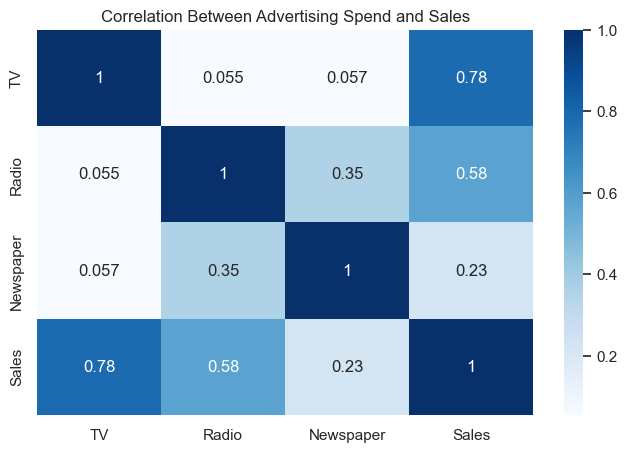

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Between Advertising Spend and Sales")
plt.show()

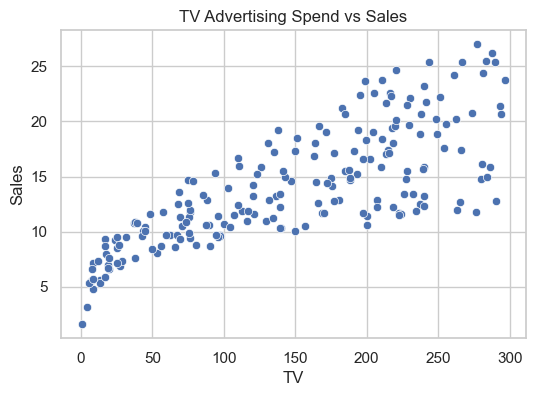

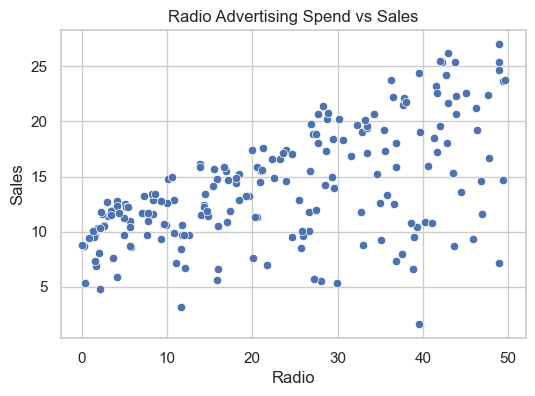

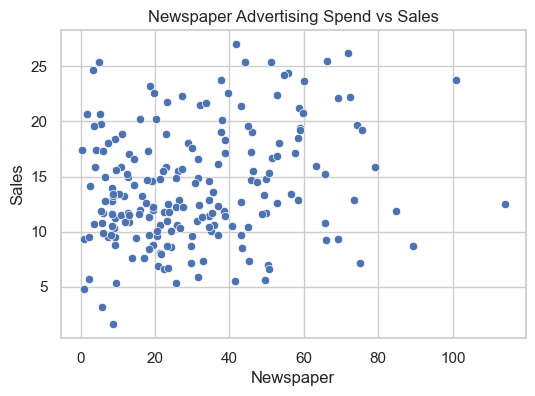

In [10]:
features = ["TV", "Radio", "Newspaper"]

for col in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="Sales")
    plt.title(f"{col} Advertising Spend vs Sales")
    plt.show()

In [11]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression Results")
print("R2 Score:", round(linear_r2, 3))
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))

Linear Regression Results
R2 Score: 0.899
MAE: 1.461
RMSE: 1.782


In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [14]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Results")
print("R2 Score:", round(rf_r2, 3))
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))

Random Forest Results
R2 Score: 0.983
MAE: 0.613
RMSE: 0.74


In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,TV,0.625447
1,Radio,0.361745
2,Newspaper,0.012808


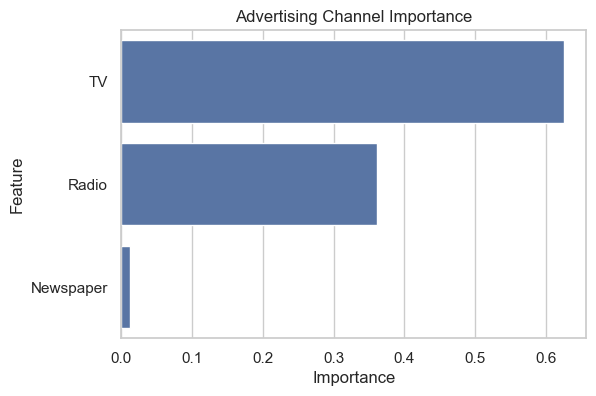

In [16]:
plt.figure(figsize=(6, 4))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Advertising Channel Importance")
plt.show()

In [17]:
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": linear_pred
})

results.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


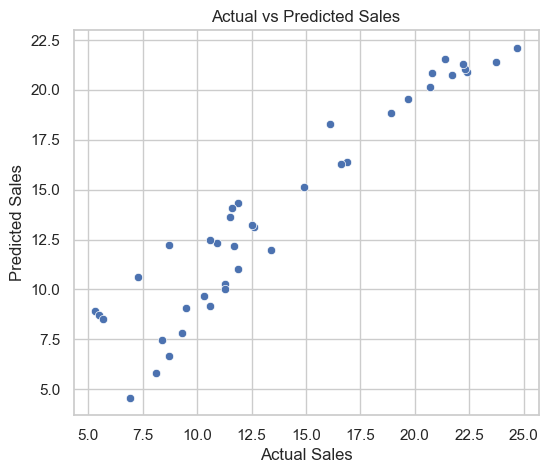

In [18]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=linear_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [19]:
new_campaigns = pd.DataFrame({
    "TV": [200, 150, 250],
    "Radio": [30, 20, 40],
    "Newspaper": [20, 10, 30]
})

future_sales = linear_model.predict(new_campaigns)

new_campaigns["Predicted Sales"] = future_sales
new_campaigns

,TV,Radio,Newspaper,Predicted Sales
0,200,30,20,17.656045
1,150,20,10,13.500007
2,250,40,30,21.812082


In [20]:
base_campaign = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [20]
})

base_prediction = linear_model.predict(base_campaign)[0]

scenario_campaign = pd.DataFrame({
    "TV": [180],
    "Radio": [35],
    "Newspaper": [20]
})

scenario_prediction = linear_model.predict(scenario_campaign)[0]

print("Base predicted sales:", round(base_prediction, 2))
print("Scenario predicted sales:", round(scenario_prediction, 2))
print("Expected sales increase:", round(scenario_prediction - base_prediction, 2))

Base predicted sales: 14.47
Scenario predicted sales: 17.71
Expected sales increase: 3.23


In [21]:
recommendations = pd.DataFrame({
    "Channel": ["TV", "Radio", "Newspaper"],
    "Business Insight": [
        "Main sales driver. Increasing TV budget is likely to improve sales strongly.",
        "Also has strong positive impact. Best used together with TV campaigns.",
        "Weakest impact in this dataset. Budget should be reviewed before increasing spend."
    ]
})

recommendations

,Channel,Business Insight
0,TV,Main sales driver. Increasing TV budget is lik...
1,Radio,Also has strong positive impact. Best used tog...
2,Newspaper,Weakest impact in this dataset. Budget should ...


In [22]:
df.to_csv(r"C:\Users\DELL\Downloads\Cleaned_Data.csv", index=False)